# Required assignment 5.1 Applying the training set–validation set–test set approach

In this notebook, you will use the training and validation sets to identify which model best fits the data. You will be working with the `train-test-split` approach from sklearn.

### **Steps followed in the `train_test_validate` approach**

1. Split the available data into a training set, a validation set and a test set.

2. Fit each model separately on the training set.

3. Evaluate each model separately on the validation set.

4. Choose the model that performs best on the validation set.

5. Estimate the performance of that model on the test set.

6. Train the selected model again using all data.

In [1]:
#Import the necessary libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Use the polynomial function to generate a data set. The function is defined as:
$$
y = 3x^3 - 2x^2 + x + 5
$$

In [2]:
# Example: generate synthetic data (replace with your own X, y)
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 3 * X.squeeze()**3 - 2 * X.squeeze()**2 + X.squeeze() + 5 + np.random.randn(100) * 100

In [9]:
y_train_val.shape

(80,)

### Step 1: Split the data into a training, a validation and a test set

#### **Question 1:** For the synthetic data set, use the `train_test_split` function to split the data into 60 per cent training , 20 per cent validation and 20 per cent test data set.

HINT: Since the `train_test_split()` function can only split the data set into two parts, follow these steps:

- The first split uses 20 per cent of the data for the test data set.

- The second split uses 25 per cent of the previous training set as the test data set.
- Then, from the remaining 80%, split off 25% for validation (which is 25% * 80% = 20% of the total).

- The leftover 60% will be the training set.

- The final proportions of the train:validate:test is 60:20:20.

In [4]:
###GRADED
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)


In [16]:
###GRADED CELL
val_errors = {}
models = {}

for degree in range(1, 7):

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    # YOUR CODE HERE
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    models[degree] = (model, poly)

#### Step 3: Evaluate each model separately on the validation data set.
# YOUR CODE HERE
y_val_pred = model.predict(X_val_poly)
mse = mean_squared_error(y_val, y_val_pred)

val_errors[degree] = mse
print(f"Degree {degree}: Validation MSE = {mse:.2f}")

Degree 1: Validation MSE = 161492.22
Degree 2: Validation MSE = 7467.75
Degree 3: Validation MSE = 8567.48
Degree 4: Validation MSE = 8117.44
Degree 5: Validation MSE = 8036.56
Degree 6: Validation MSE = 8060.76


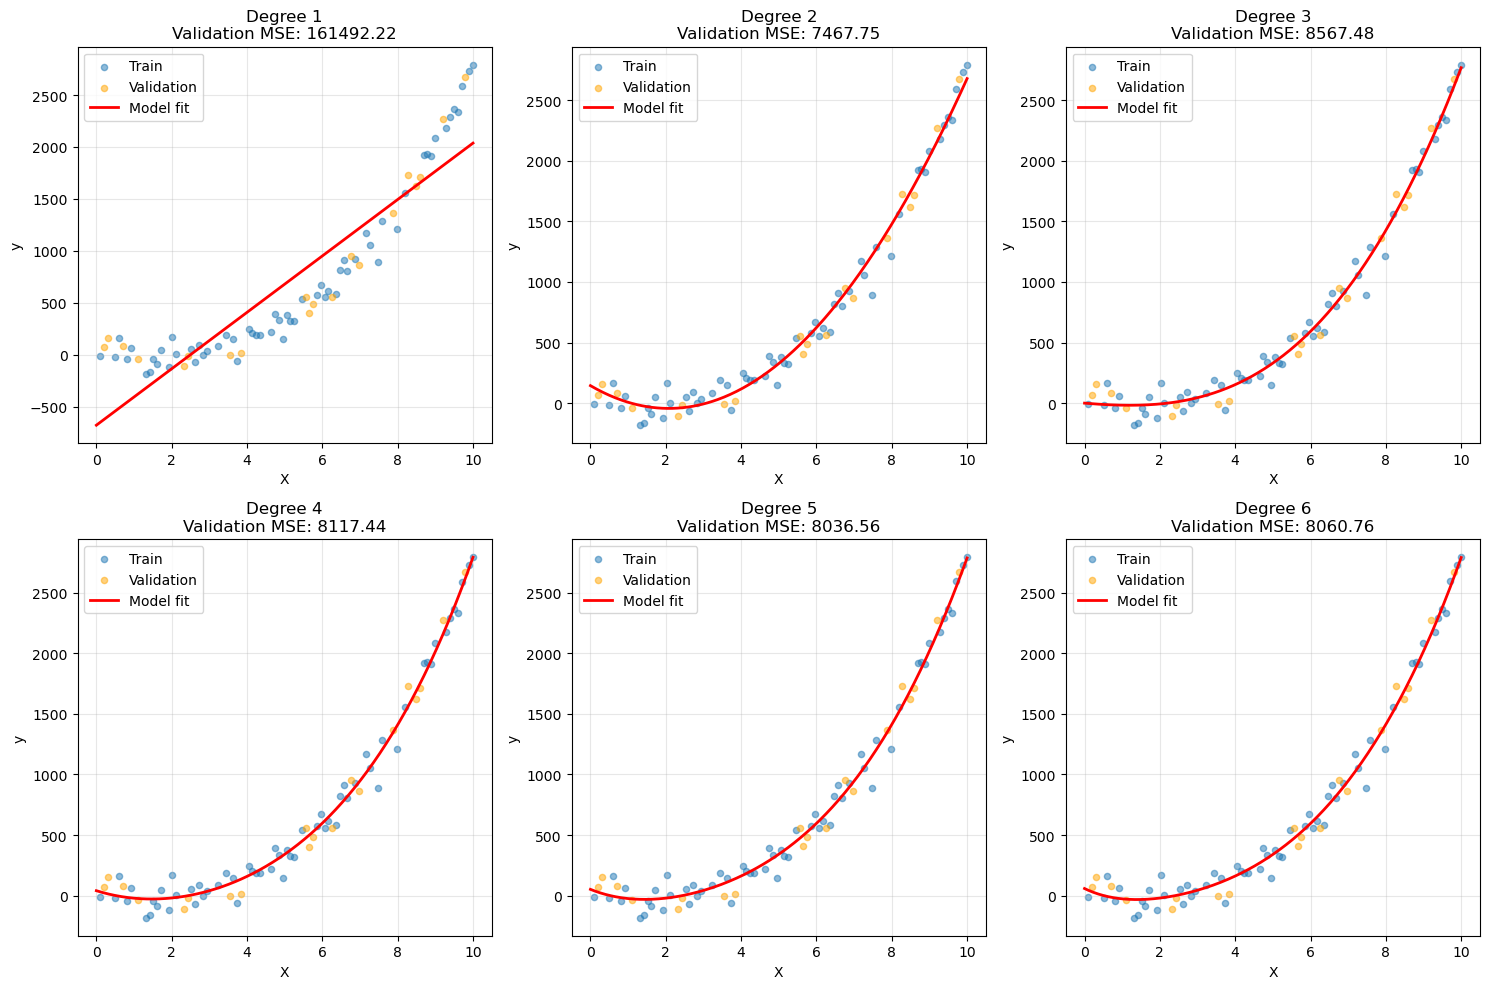

In [20]:
from matplotlib import pyplot as plt

###GRADED CELL
val_errors = {}
models = {}

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for degree in range(1, 7):

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    # Question 2: Train the model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Question 3: Evaluate on validation set
    y_val_pred = model.predict(X_val_poly)
    mse = mean_squared_error(y_val, y_val_pred)

    val_errors[degree] = mse
    print(f"Degree {degree}: Validation MSE = {mse:.2f}")

    models[degree] = (model, poly)

    # VISUALIZATION: Plot the fit
    ax = axes[degree - 1]

    # Plot training data
    ax.scatter(X_train, y_train, alpha=0.5, label='Train', s=20)
    # Plot validation data
    ax.scatter(X_val, y_val, alpha=0.5, label='Validation', s=20, color='orange')

    # Create smooth line for predictions
    X_plot = np.linspace(0, 10, 300).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot = model.predict(X_plot_poly)

    ax.plot(X_plot, y_plot, 'r-', linewidth=2, label='Model fit')
    ax.set_title(f'Degree {degree}\nValidation MSE: {mse:.2f}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Step 4: Choose the model that performs best on the validation set.

#### **Question 4**: Choose the best model that has the mininum error and print the degree of that model.

min_error_degree = min(val_errors, key=val_errors.get)
min_error_degree

In [22]:
###GRADED

# YOUR CODE HERE
best_degree = min(val_errors, key=val_errors.get)

print(f"Best polynomial degree: {best_degree}")


Best polynomial degree: 2


In [23]:
val_errors

{1: 161492.22004382376,
 2: 7467.752232598173,
 3: 8567.484168910729,
 4: 8117.443867098079,
 5: 8036.561469643343,
 6: 8060.761069468981}

#### Step 5: Estimate the performance of that model on the test set.

#### **Question 5**: Estimate the performance on the test set.

In [24]:
###GRADED
best_model, best_poly = models[best_degree]
X_test_poly = best_poly.transform(X_test)

# YOUR CODE HERE
y_test_pred = best_model.predict(X_test_poly)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Test MSE for best model (degree {best_degree}): {test_mse:.2f}")

Test MSE for best model (degree 2): 7816.15


#### Step 6: Retrain the best model on all available data.

In [25]:
best_poly_full = PolynomialFeatures(degree=best_degree)
X_full_poly = best_poly_full.fit_transform(X)
final_model = LinearRegression()
final_model.fit(X_full_poly, y)
print(f"Retrained best polynomial model (degree {best_degree}) on all data.")

Retrained best polynomial model (degree 2) on all data.
